# PROJECT OVERVIEW

This project analyses hostorical commodity data to derive insights on price trends betwwen the years 2000 & 2026. The project demostrates a data analytics workflow including a defined business objective/question, data collection, cleaning, transformatioan, alysis and visualization.

The tools used for this project include, a dataset from kaggle, google collab, python, pandas, matplot, numpy and Microsoft Power BI.



# Dataset

Source: https://www.kaggle.com/datasets/ibrahimqasimi/global-commodity-prices-2000-2026

Data Columns: Date, Open, High, Low, Close, Volume, Ticker, Commodity

**Data Stats**:
1. Total rows: 38,002
2. Time span: 2000 to March 2026
3. Gold range: ~$250 to $3,000+ per oz
4. Oil range: ~$10 to $145 per barrel

**Data Notes**:
1. Volume is 0 on some days (settlement-only or illiquid)
2. Prices are auto-adjusted for contract rollovers
3. Futures contracts — not spot prices (slight differences)
4. Weekends and holidays have no rows

In [ ]:
#load csv file
import pandas as pd

commodities_df = pd.read_csv("/content/Global_Commodity_Prices_2000_2026.csv")

The first step is to import the data into a data frame. Its structure and contents are inspected by checking the first 5 columns of the dataset. Its also important to check the data summary for the numerical values by using the describe method. For an instance, for Open there are 37996 total number of values, with a mean value of 399, min value being -14, and max being 5415.7. This method is important as from the data description, there are 38002 rows so an assumption can be made that this attribute may have missing values.

In [ ]:
#check first 5 columns
commodities_df.head()26

,Date,Open,High,Low,Close,Volume,Ticker,Commodity
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,GC=F,Gold
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,GC=F,Gold
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,GC=F,Gold
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,GC=F,Gold
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,GC=F,Gold


In [ ]:
#check data summary
commodities_df.describe()

,Open,High,Low,Close,Volume
count,37996.000000,37996.000000,37996.000000,37996.000000,3.800200e+04
mean,399.187597,401.075556,397.258523,399.217656,7.066583e+04
std,656.025483,659.250068,652.622823,655.992127,1.437350e+05
min,-14.000000,0.609500,-40.320000,-37.630001,0.000000e+00
25%,4.212375,4.261000,4.154750,4.214750,4.000000e+01
50%,29.549999,29.952500,29.160000,29.549500,4.570000e+02
75%,791.000015,793.725006,788.024994,790.500000,8.397550e+04
max,5415.700195,5586.200195,5301.600098,5318.399902,2.288230e+06


In [ ]:
#check data types and null values
commodities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38002 entries, 0 to 38001
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       38002 non-null  object 
 1   Open       37996 non-null  float64
 2   High       37996 non-null  float64
 3   Low        37996 non-null  float64
 4   Close      37996 non-null  float64
 5   Volume     38002 non-null  int64  
 6   Ticker     38002 non-null  object 
 7   Commodity  38002 non-null  object 
dtypes: float64(4), int64(1), object(3)
memory usage: 2.3+ MB


To further investigate the issue of missing or null values, the method info is useful as it gives the entire picture of non-null values for each attribute as shown above.
Depending on the industry, null values can be flagged for a number of reasons.
1. It may be a vendor issue whete there is a mulfunction in data collection. In that case this needs to be taken up with the necessary department by sending the list of records with null values.
2. Auditing purposes. Heavilly regulated industries require transparency. Any data left out needs to be presented in the correct matter.
A list of null value records is compiled and saved to send to manager if needed as shown below.

In [ ]:
from google.colab import files

null_values = commodities_df[commodities_df.isnull().any(axis = 1)]

print(null_values)

#write them to an excel sheet
null_values.to_excel("null_values.xlsx", index = "False")

#Automatically download it to your computer
#files.download("null_values.xlsx")

             Date  Open  High  Low  Close  Volume Ticker      Commodity
6415   2026-03-26   NaN   NaN  NaN    NaN    2535   GC=F           Gold
12833  2026-03-26   NaN   NaN  NaN    NaN     498   SI=F         Silver
19258  2026-03-26   NaN   NaN  NaN    NaN    2687   CL=F  Crude Oil WTI
25680  2026-03-26   NaN   NaN  NaN    NaN     244   NG=F    Natural Gas
32101  2026-03-26   NaN   NaN  NaN    NaN     352   HG=F         Copper
38001  2026-03-26   NaN   NaN  NaN    NaN     290   PL=F       Platinum


# Data Cleaning
1. Fix data types- the info method shows that date, ticker and commodity are shown as object.
2. Drop Ticker- Commodity attribute makes more sense to the average person and is pretty much the same meaning as ticker.The less meaningful attribute needs to be dropped.

In [ ]:
#change date attribute data type
commodities_df["Date"] = pd.to_datetime(commodities_df["Date"])
#index date column
#change commodity to string
commodities_df["Commodity"] = commodities_df["Commodity"].astype("string")

In [ ]:
commodities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38002 entries, 0 to 38001
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       38002 non-null  datetime64[ns]
 1   Open       37996 non-null  float64       
 2   High       37996 non-null  float64       
 3   Low        37996 non-null  float64       
 4   Close      37996 non-null  float64       
 5   Volume     38002 non-null  int64         
 6   Ticker     38002 non-null  object        
 7   Commodity  38002 non-null  string        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1), string(1)
memory usage: 2.3+ MB


In [ ]:
#drop columns index and ticker
commodities_df = commodities_df.drop(["Ticker"], axis=1)

In [ ]:
commodities_df


,Date,Open,High,Low,Close,Volume,Commodity
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,Gold
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,Gold
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,Gold
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,Gold
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,Gold
...,...,...,...,...,...,...,...
37997,2026-03-20,1970.599976,1970.599976,1970.599976,1970.599976,0,Platinum
37998,2026-03-23,1860.300049,1860.300049,1860.300049,1860.300049,2,Platinum
37999,2026-03-24,1892.000000,1892.000000,1892.000000,1892.000000,18,Platinum
38000,2026-03-25,1925.199951,1925.199951,1925.199951,1925.199951,18,Platinum


## Dealing With Null Values

When dealing with trading data its usually best to replace null values instead of dropping the entire records. In this case since its a very small percentage of the entire data set, they are replaced with the mean value of each attribute.
Every step is contantly checked, hence why the data frame is called to show the top 5 records and top bottom records, confirming the null values have been attended to.

In [ ]:
#replace null values with mean
columns = ["Open", "High", "Low", "Close"]

commodities_df[columns] = commodities_df[columns].fillna(commodities_df[columns].mean())

In [ ]:
commodities_df

,Date,Open,High,Low,Close,Volume,Commodity
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,Gold
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,Gold
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,Gold
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,Gold
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,Gold
...,...,...,...,...,...,...,...
37997,2026-03-20,1970.599976,1970.599976,1970.599976,1970.599976,0,Platinum
37998,2026-03-23,1860.300049,1860.300049,1860.300049,1860.300049,2,Platinum
37999,2026-03-24,1892.000000,1892.000000,1892.000000,1892.000000,18,Platinum
38000,2026-03-25,1925.199951,1925.199951,1925.199951,1925.199951,18,Platinum


In [ ]:
#remove any trailing white spaces from Commodity

commodities_df["Commodity"] = commodities_df["Commodity"].str.strip()

commodities_df.head()

,Date,Open,High,Low,Close,Volume,Commodity
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,Gold
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,Gold
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,Gold
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,Gold
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,Gold


<Axes: >

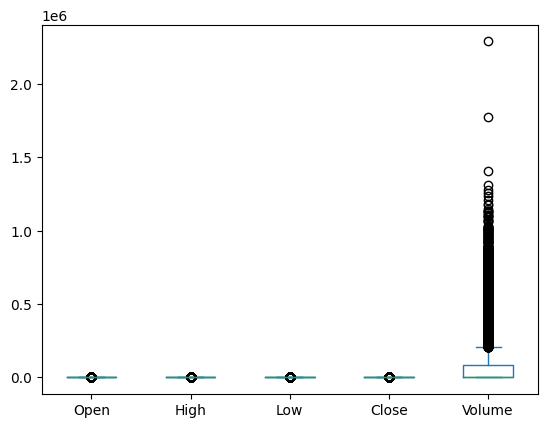

In [ ]:
#check data distribution for outliers

import matplotlib.pyplot as plt

commodities_df.plot.box()

## Outliers

Its important to run visuals on outliers to check how its distributed. The context in this case is trading data. Spikes of high volumes are not unusual so typically should be left alone.



In [ ]:
commodities_df['Volume'].describe()

,Volume
count,3.800200e+04
mean,7.066583e+04
std,1.437350e+05
min,0.000000e+00
25%,4.000000e+01
50%,4.570000e+02
75%,8.397550e+04
max,2.288230e+06


<Axes: ylabel='Frequency'>

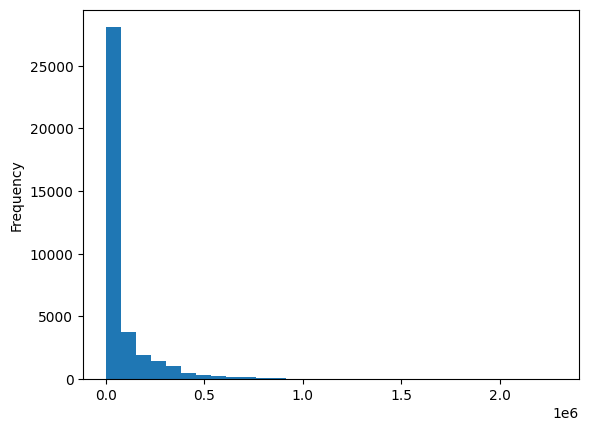

In [ ]:
commodities_df["Volume"].plot.hist(bins=30)

## Skewed Data

Volume data is right skewed from the histogram above. A log transformation is performed on this attribute, to safely handle zero. Information got from the data description. This is done within each commodity for accuracy.

In [ ]:
import numpy as np
#within each commodity

commodities_df["Volume"] = (
    commodities_df.groupby("Commodity")["Volume"]
    .transform(lambda x: np.log1p(x))
)

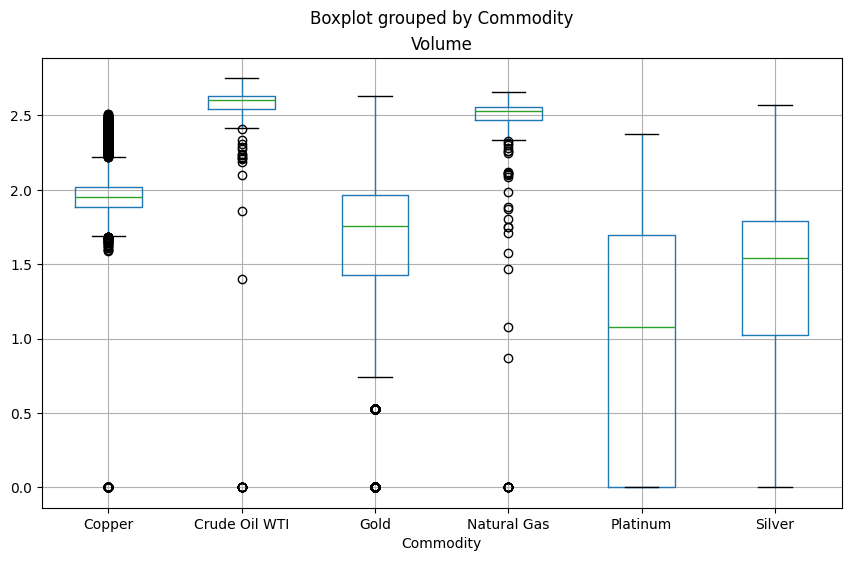

In [ ]:
#plot distribution by commodity
commodities_df.(column="Volume", by="Commodity", figsize=(10, 6))
plt.show()

In [ ]:
#save cleaned data as a csv.

clean_data = commodities_df.to_csv("cleaned_data.csv", index=False)

#files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PowerBI

The data is now clean and is downloaded into a csv called "cleaned_data" that can now be used to create dashboard in Microsoft Power BI.
A screenshot of the dashboard is shown below with the QR to be viewed on the Power BI App.

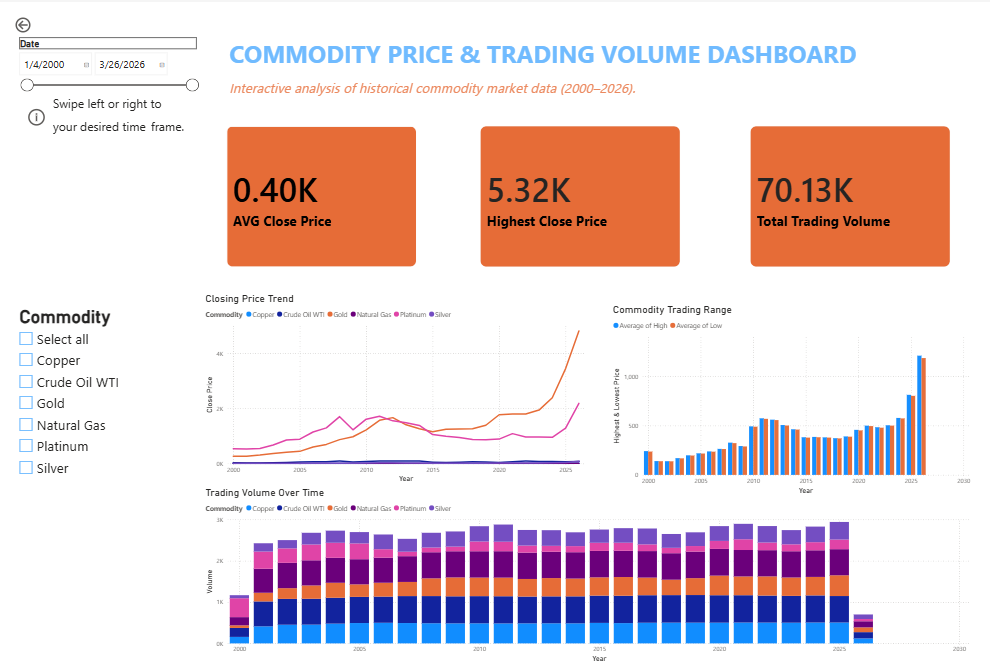

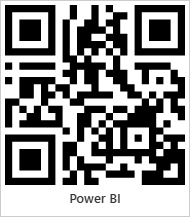